In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")

In [2]:
# Load the e-commerce fraud data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')

print("Data loaded successfully!")
print(f"Shape: {fraud_df.shape}")

Data loaded successfully!
Shape: (151112, 11)


In [3]:
# Dataset shape and sample
print("Dataset Shape:")
print(f"Rows: {fraud_df.shape[0]:,}")
print(f"Columns: {fraud_df.shape[1]}")
print("\nFirst 5 rows:")
fraud_df.head()

Dataset Shape:
Rows: 151,112
Columns: 11

First 5 rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
# Data types
print("Data Types:")
print(fraud_df.dtypes)
print("\nMissing Values:")
print(fraud_df.isnull().sum())

Data Types:
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object

Missing Values:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


In [5]:
# Statistical summary
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


Class Distribution:
class
0    136961
1     14151
Name: count, dtype: int64

Percentages:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


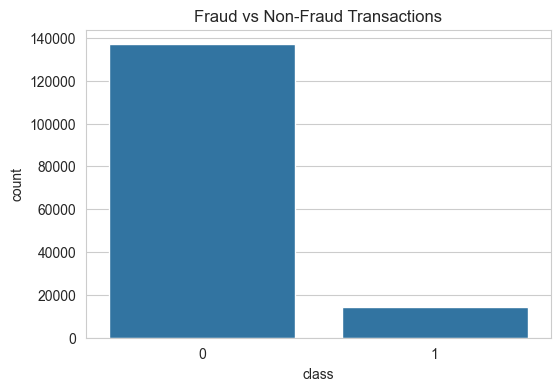

In [6]:
# Class distribution - how imbalanced is our data?
class_counts = fraud_df['class'].value_counts()
print("Class Distribution:")
print(class_counts)
print("\nPercentages:")
print(fraud_df['class'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(data=fraud_df, x='class')
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [7]:
# Check categorical columns
categorical_cols = ['source', 'browser', 'sex']
for col in categorical_cols:
    print(f"\n{col.upper()} distribution:")
    print(fraud_df[col].value_counts())
    print(fraud_df[col].value_counts(normalize=True) * 100)


SOURCE distribution:
source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64
source
SEO       40.112632
Ads       39.626899
Direct    20.260469
Name: proportion, dtype: float64

BROWSER distribution:
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64
browser
Chrome     40.653290
IE         24.304489
Safari     16.323654
FireFox    16.285934
Opera       2.432633
Name: proportion, dtype: float64

SEX distribution:
sex
M    88293
F    62819
Name: count, dtype: int64
sex
M    58.428847
F    41.571153
Name: proportion, dtype: float64


In [8]:
# Fraud rate by source
print("Fraud Rate by Source:")
fraud_by_source = fraud_df.groupby('source')['class'].mean() * 100
print(fraud_by_source.sort_values(ascending=False))

# Fraud rate by browser
print("\nFraud Rate by Browser:")
fraud_by_browser = fraud_df.groupby('browser')['class'].mean() * 100
print(fraud_by_browser.sort_values(ascending=False))

# Fraud rate by sex
print("\nFraud Rate by Sex:")
fraud_by_sex = fraud_df.groupby('sex')['class'].mean() * 100
print(fraud_by_sex)

Fraud Rate by Source:
source
Direct    10.536974
Ads        9.206593
SEO        8.928483
Name: class, dtype: float64

Fraud Rate by Browser:
browser
Chrome     9.879216
FireFox    9.516457
Safari     9.020148
Opera      8.922742
IE         8.677540
Name: class, dtype: float64

Fraud Rate by Sex:
sex
F    9.100750
M    9.552286
Name: class, dtype: float64


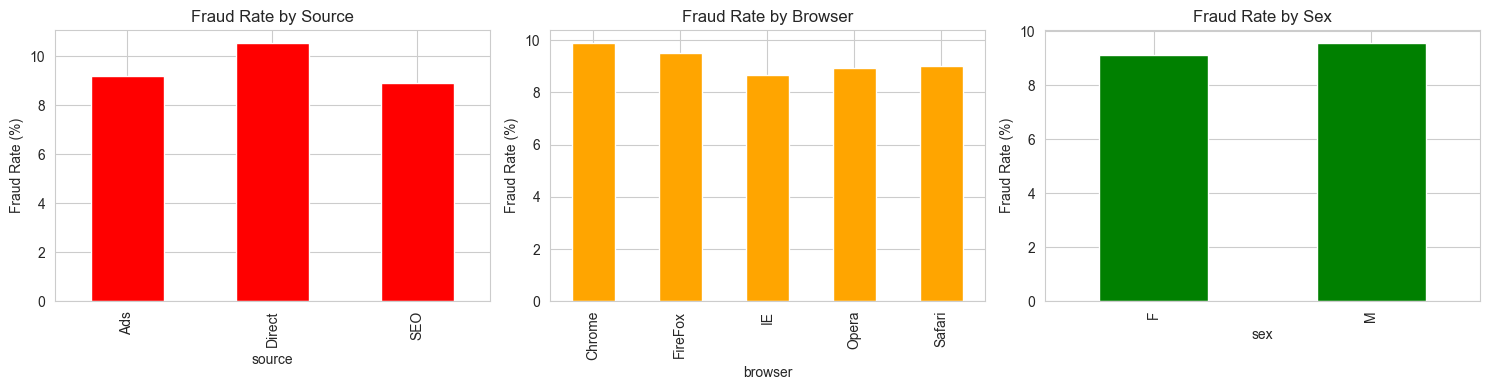

In [9]:
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fraud by source
fraud_by_source.plot(kind='bar', ax=axes[0], color='red')
axes[0].set_title('Fraud Rate by Source')
axes[0].set_ylabel('Fraud Rate (%)')

# Fraud by browser
fraud_by_browser.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Fraud Rate by Browser')
axes[1].set_ylabel('Fraud Rate (%)')

# Fraud by sex
fraud_by_sex.plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Fraud Rate by Sex')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

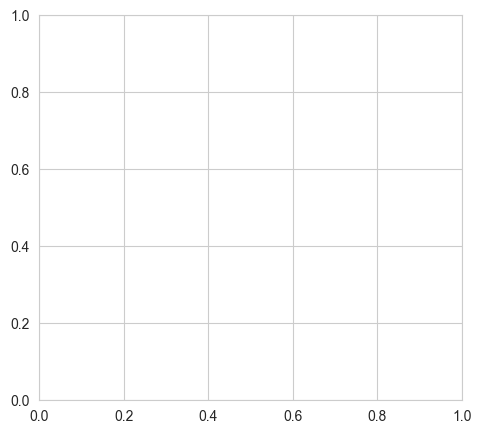

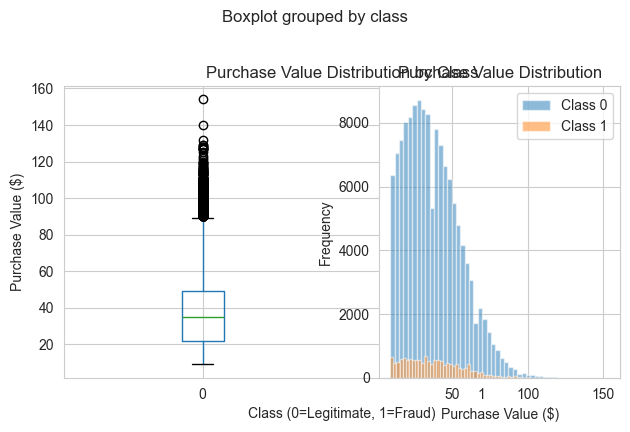

Purchase Value Statistics:
          count       mean        std  min   25%   50%   75%    max
class                                                              
0      136961.0  36.929418  18.315064  9.0  22.0  35.0  49.0  154.0
1       14151.0  36.993004  18.397654  9.0  22.0  35.0  49.0  111.0


In [10]:
# Compare purchase value between fraud and non-fraud
plt.figure(figsize=(12, 5))

# Box plot
plt.subplot(1, 2, 1)
fraud_df.boxplot(column='purchase_value', by='class')
plt.title('Purchase Value Distribution by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Purchase Value ($)')

# Histogram
plt.subplot(1, 2, 2)
for class_val in [0, 1]:
    subset = fraud_df[fraud_df['class'] == class_val]
    plt.hist(subset['purchase_value'], bins=50, alpha=0.5, label=f'Class {class_val}')
plt.title('Purchase Value Distribution')
plt.xlabel('Purchase Value ($)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print("Purchase Value Statistics:")
print(fraud_df.groupby('class')['purchase_value'].describe())

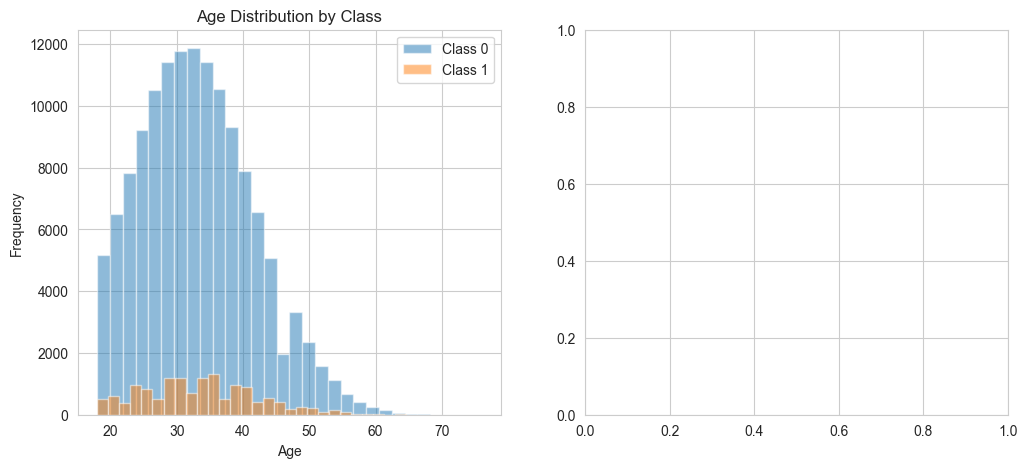

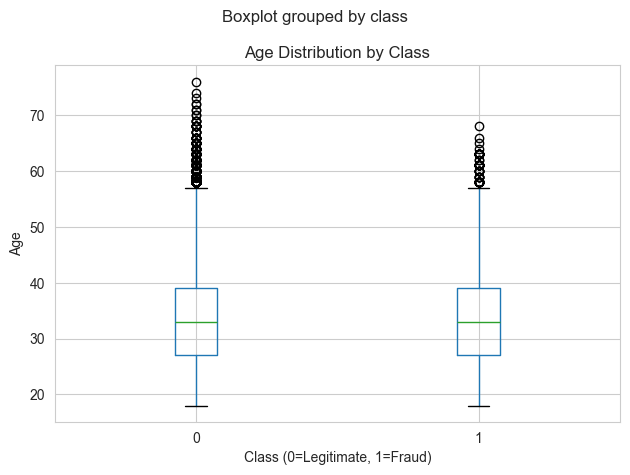

Age Statistics:
          count       mean       std   min   25%   50%   75%   max
class                                                             
0      136961.0  33.122356  8.622678  18.0  27.0  33.0  39.0  76.0
1       14151.0  33.318281  8.568001  18.0  27.0  33.0  39.0  68.0


In [11]:
# Age distribution by fraud status
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for class_val in [0, 1]:
    subset = fraud_df[fraud_df['class'] == class_val]
    plt.hist(subset['age'], bins=30, alpha=0.5, label=f'Class {class_val}')
plt.title('Age Distribution by Class')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
fraud_df.boxplot(column='age', by='class')
plt.title('Age Distribution by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

print("Age Statistics:")
print(fraud_df.groupby('class')['age'].describe())

In [12]:
# Convert to datetime
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Create time-based features
fraud_df['time_since_signup'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds() / 3600  # in hours
fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour
fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.dayofweek

print("Time features created!")
print(fraud_df[['time_since_signup', 'hour_of_day', 'day_of_week']].head())

Time features created!
   time_since_signup  hour_of_day  day_of_week
0        1251.856111            2            5
1           4.984444            1            0
2           0.000278           18            3
3         136.690278           13            0
4        1211.516944           18            2


Time Since Signup Statistics (hours):
          count         mean         std       min         25%          50%  \
class                                                                         
0      136961.0  1441.994052  830.163558  0.038056  719.119167  1443.030833   
1       14151.0   673.289542  920.496897  0.000278    0.000278     0.000278   

               75%          max  
class                            
0      2161.477500  2879.992222  
1      1330.697361  2878.874167  


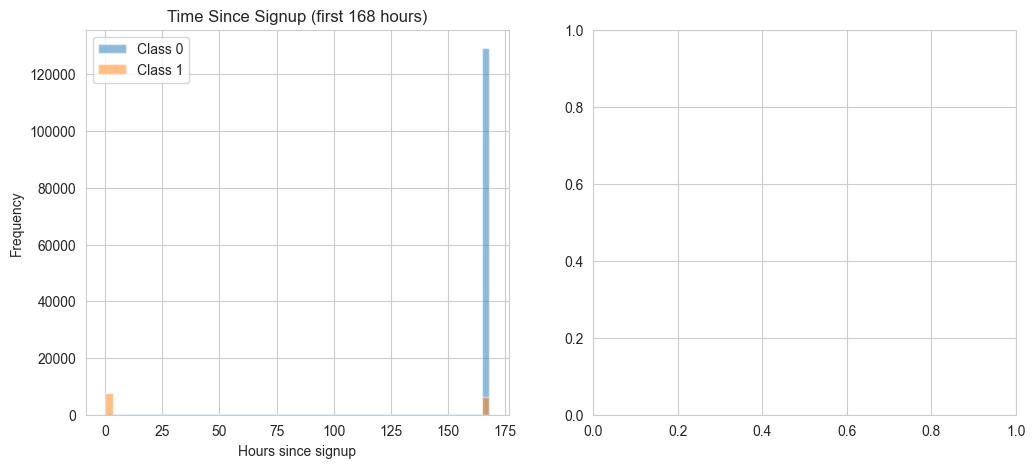

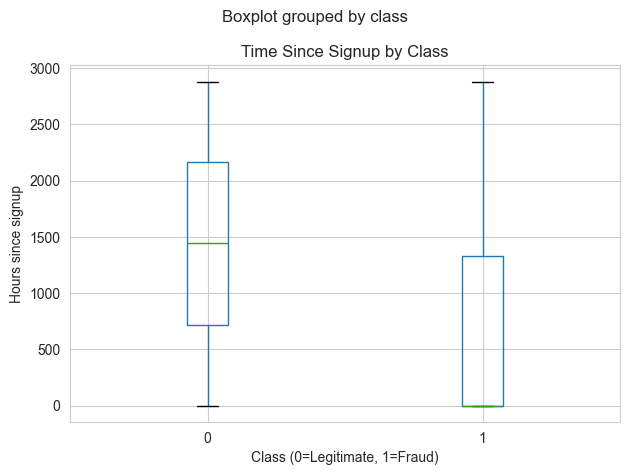

Percentage of fraud among transactions within 24 hours of signup: 87.33%


In [13]:
# Time since signup analysis
print("Time Since Signup Statistics (hours):")
print(fraud_df.groupby('class')['time_since_signup'].describe())

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for class_val in [0, 1]:
    subset = fraud_df[fraud_df['class'] == class_val]
    plt.hist(subset['time_since_signup'].clip(upper=168), bins=50, alpha=0.5, label=f'Class {class_val}')
plt.title('Time Since Signup (first 168 hours)')
plt.xlabel('Hours since signup')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
fraud_df.boxplot(column='time_since_signup', by='class')
plt.title('Time Since Signup by Class')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Hours since signup')

plt.tight_layout()
plt.show()

# Key insight: Fraud often happens soon after signup
fraud_early = fraud_df[fraud_df['time_since_signup'] <= 24]['class'].mean() * 100
print(f"Percentage of fraud among transactions within 24 hours of signup: {fraud_early:.2f}%")

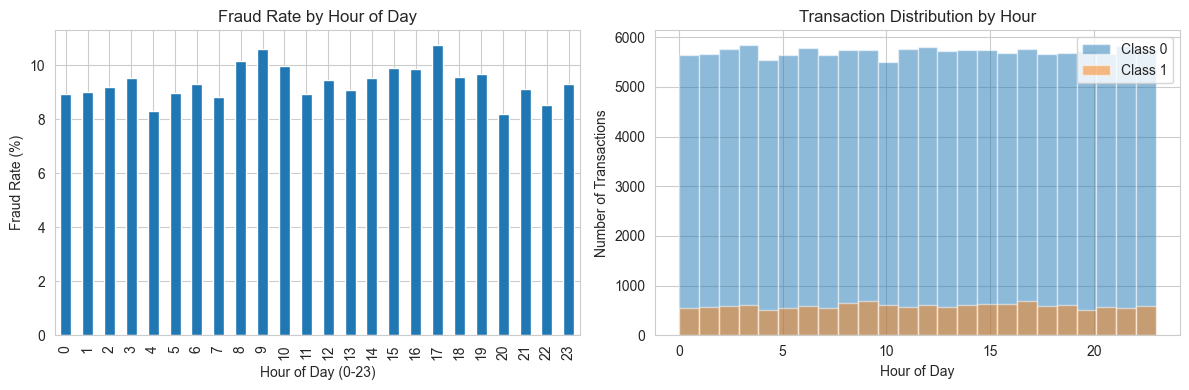

Top 5 hours with highest fraud rate:
hour_of_day
17    10.748531
9     10.579620
8     10.145608
10     9.967213
15     9.907364
Name: class, dtype: float64


In [14]:
# Hour of day analysis
plt.figure(figsize=(12, 5))

# Fraud rate by hour
hourly_fraud_rate = fraud_df.groupby('hour_of_day')['class'].mean() * 100

plt.subplot(1, 2, 1)
hourly_fraud_rate.plot(kind='bar', figsize=(12, 4))
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')

plt.subplot(1, 2, 2)
# Distribution of transactions by hour
for class_val in [0, 1]:
    subset = fraud_df[fraud_df['class'] == class_val]
    plt.hist(subset['hour_of_day'], bins=24, alpha=0.5, label=f'Class {class_val}')
plt.title('Transaction Distribution by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.legend()

plt.tight_layout()
plt.show()

print("Top 5 hours with highest fraud rate:")
print(hourly_fraud_rate.nlargest(5))

Devices with most transactions:
               transaction_count  fraud_rate
device_id                                   
CQTUVBYIWWWBC                 20    0.950000
ITUMJCKWEYNDD                 20    0.950000
NGQCKIADMZORL                 20    0.950000
EQYVNEGOFLAWK                 20    0.950000
KIPFSCNUGOLDP                 20    0.950000
ZUSVMDEZRBDTX                 20    0.950000
EGLGSEGYPMMAM                 19    0.947368
CDFXVYHOIHPYP                 19    0.947368
SDJQRPKXQFBED                 19    0.947368
BWSMVSLCJXMCM                 19    0.947368


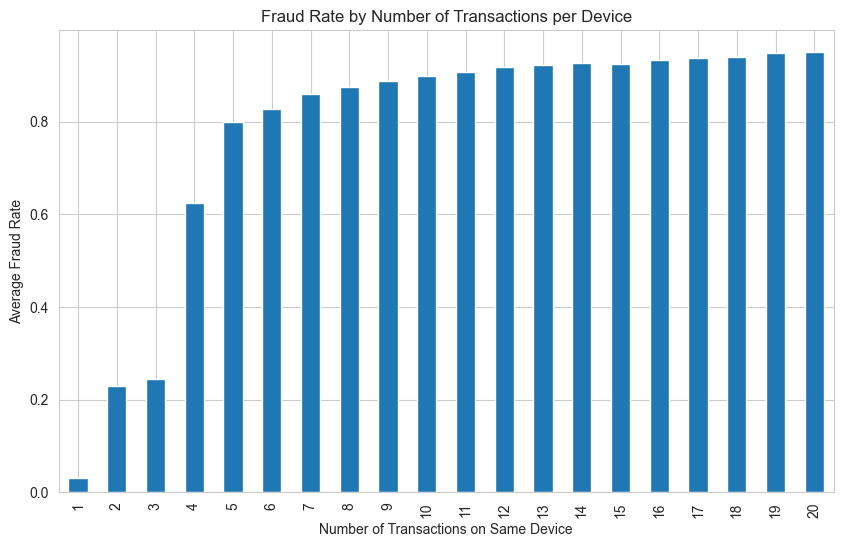

In [15]:
# Transaction velocity - same device used multiple times
device_counts = fraud_df.groupby('device_id')['class'].agg(['count', 'mean'])
device_counts.columns = ['transaction_count', 'fraud_rate']
device_counts = device_counts.sort_values('transaction_count', ascending=False)

print("Devices with most transactions:")
print(device_counts.head(10))

# Fraud rate by number of transactions per device
plt.figure(figsize=(10, 6))
device_counts.groupby('transaction_count')['fraud_rate'].mean().plot(kind='bar')
plt.title('Fraud Rate by Number of Transactions per Device')
plt.xlabel('Number of Transactions on Same Device')
plt.ylabel('Average Fraud Rate')
plt.show()

In [16]:
# Print summary of key insights
print("="*60)
print("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS")
print("="*60)

print("\n1. CLASS IMBALANCE:")
print(f"   - Fraud cases: {fraud_df['class'].sum():,} ({fraud_df['class'].mean()*100:.2f}%)")
print(f"   - Legitimate cases: {(~fraud_df['class'].astype(bool)).sum():,} ({(1-fraud_df['class'].mean())*100:.2f}%)")

print("\n2. HIGH RISK CHANNELS:")
print(f"   - Direct source has highest fraud rate: {fraud_by_source['Direct']:.2f}%")

print("\n3. TIME-BASED INSIGHTS:")
print(f"   - Transactions within 24h of signup have {fraud_early:.2f}% fraud rate")
print(f"   - Peak fraud hours: {hourly_fraud_rate.nlargest(3).index.tolist()}")

print("\n4. NEXT STEPS (Task 1 continues):")
print("   - IP to Country mapping")
print("   - Feature engineering (velocity, time features)")
print("   - Handle class imbalance with SMOTE")

KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. CLASS IMBALANCE:
   - Fraud cases: 14,151 (9.36%)
   - Legitimate cases: 136,961 (90.64%)

2. HIGH RISK CHANNELS:
   - Direct source has highest fraud rate: 10.54%

3. TIME-BASED INSIGHTS:
   - Transactions within 24h of signup have 87.33% fraud rate
   - Peak fraud hours: [17, 9, 8]

4. NEXT STEPS (Task 1 continues):
   - IP to Country mapping
   - Feature engineering (velocity, time features)
   - Handle class imbalance with SMOTE


In [17]:
# Load IP to Country data
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Convert IP addresses to integer (handle numeric values)
def ip_to_int(ip):
    # If ip is already a number, return it
    if isinstance(ip, (int, float)):
        return int(ip)
    # If it's a string with dots, convert it
    if isinstance(ip, str) and '.' in ip:
        parts = ip.split('.')
        return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    # If it's just a number as string
    return int(ip)

# Convert IP ranges to integers
ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)

print("IP mapping loaded!")
print(ip_df.head())

IP mapping loaded!
   lower_bound_ip_address  upper_bound_ip_address    country  lower_int  \
0              16777216.0                16777471  Australia   16777216   
1              16777472.0                16777727      China   16777472   
2              16777728.0                16778239      China   16777728   
3              16778240.0                16779263  Australia   16778240   
4              16779264.0                16781311      China   16779264   

   upper_int  
0   16777471  
1   16777727  
2   16778239  
3   16779263  
4   16781311  


In [18]:
print("Hello - testing if code runs")
print(fraud_df.shape)

Hello - testing if code runs
(151112, 14)


In [19]:
# Load IP data
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
print(f"IP data loaded: {ip_df.shape}")
print(ip_df.head())

IP data loaded: (138846, 3)
   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1              16777472.0                16777727      China
2              16777728.0                16778239      China
3              16778240.0                16779263  Australia
4              16779264.0                16781311      China


In [20]:
# Convert IP ranges to integers
def ip_to_int(ip):
    if isinstance(ip, str) and '.' in ip:
        parts = ip.split('.')
        return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    return int(ip)

ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)
print(f"IP ranges converted")
print(ip_df[['lower_bound_ip_address', 'lower_int', 'upper_int']].head())

IP ranges converted
   lower_bound_ip_address  lower_int  upper_int
0              16777216.0   16777216   16777471
1              16777472.0   16777472   16777727
2              16777728.0   16777728   16778239
3              16778240.0   16778240   16779263
4              16779264.0   16779264   16781311


In [23]:
# Check existing columns in fraud_df
print("Current columns in fraud_df:")
print(fraud_df.columns.tolist())

Current columns in fraud_df:
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week']


In [24]:
# Create ip_int column from ip_address
fraud_df['ip_int'] = fraud_df['ip_address'].astype(int)
print("✓ ip_int column created")
print(fraud_df[['ip_address', 'ip_int']].head())

✓ ip_int column created
     ip_address      ip_int
0  7.327584e+08   732758368
1  3.503114e+08   350311387
2  2.621474e+09  2621473820
3  3.840542e+09  3840542443
4  4.155831e+08   415583117


In [25]:
# Reload IP data if needed
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Convert IP ranges to integers
def ip_to_int(ip):
    if isinstance(ip, str) and '.' in ip:
        parts = ip.split('.')
        return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])
    return int(ip)

ip_df['lower_int'] = ip_df['lower_bound_ip_address'].apply(ip_to_int)
ip_df['upper_int'] = ip_df['upper_bound_ip_address'].apply(ip_to_int)

print("IP ranges converted")
print(ip_df.head())

IP ranges converted
   lower_bound_ip_address  upper_bound_ip_address    country  lower_int  \
0              16777216.0                16777471  Australia   16777216   
1              16777472.0                16777727      China   16777472   
2              16777728.0                16778239      China   16777728   
3              16778240.0                16779263  Australia   16778240   
4              16779264.0                16781311      China   16779264   

   upper_int  
0   16777471  
1   16777727  
2   16778239  
3   16779263  
4   16781311  


In [26]:
# Sort for merge_asof
ip_df_sorted = ip_df.sort_values('lower_int')
fraud_df_sorted = fraud_df.sort_values('ip_int')

# Merge
result = pd.merge_asof(
    fraud_df_sorted[['ip_int']], 
    ip_df_sorted[['lower_int', 'country']], 
    left_on='ip_int', 
    right_on='lower_int',
    direction='backward'
)

# Add back to original
fraud_df['country'] = result['country']
fraud_df['country'] = fraud_df['country'].fillna('Unknown')

print("Mapping complete!")
print("\nTop 10 countries by count:")
print(fraud_df['country'].value_counts().head(10))

Mapping complete!

Top 10 countries by count:
country
United States        59222
Australia            21228
China                12038
Japan                 7918
United Kingdom        4492
Korea Republic of     4162
Germany               3647
France                3163
Canada                2981
Brazil                2961
Name: count, dtype: int64


FRAUD RATE BY COUNTRY

Top 10 Countries by Fraud Rate (min 500 transactions):
                   total_transactions  fraud_rate  fraud_percentage
country                                                            
South Africa                      838    0.110979         11.097852
Indonesia                         649    0.109399         10.939908
Unknown                           634    0.105678         10.567823
Germany                          3647    0.100356         10.035646
Argentina                         661    0.098336          9.833585
Korea Republic of                4162    0.098030          9.802979
Italy                            1946    0.097122          9.712230
Sweden                           1090    0.096330          9.633028
Brazil                           2961    0.095914          9.591354
Netherlands                      1825    0.095890          9.589041


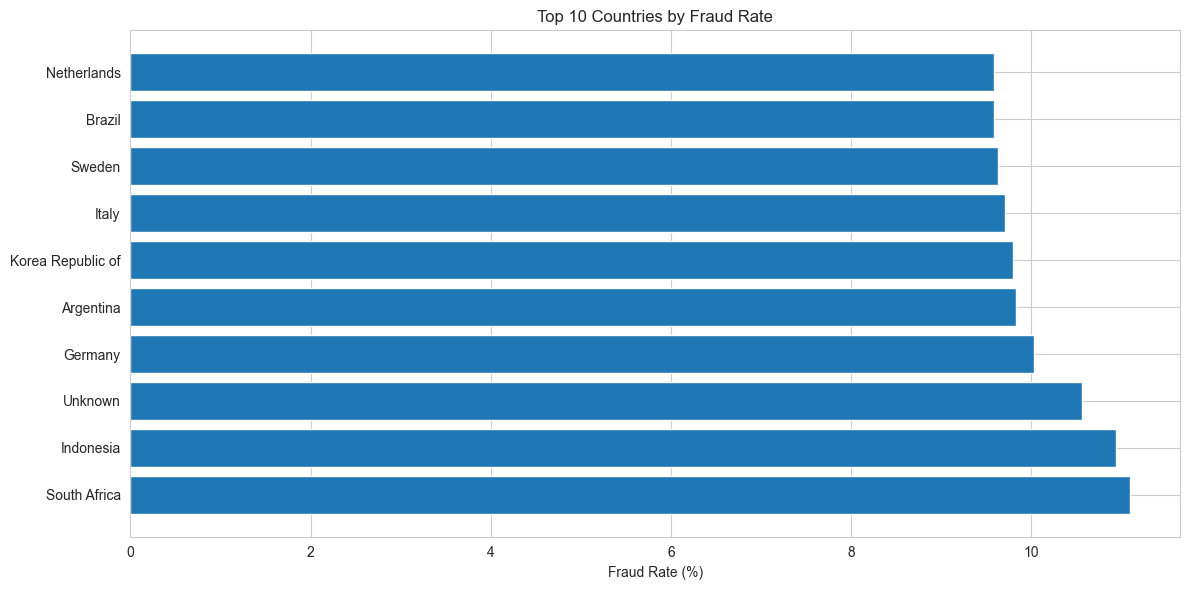

In [27]:
# Fraud rate by country
print("="*50)
print("FRAUD RATE BY COUNTRY")
print("="*50)

# Calculate fraud rate per country
country_fraud = fraud_df.groupby('country')['class'].agg(['count', 'mean'])
country_fraud.columns = ['total_transactions', 'fraud_rate']
country_fraud['fraud_percentage'] = country_fraud['fraud_rate'] * 100

# Filter for countries with at least 500 transactions for meaningful data
country_fraud_filtered = country_fraud[country_fraud['total_transactions'] >= 500]
country_fraud_filtered = country_fraud_filtered.sort_values('fraud_rate', ascending=False)

print("\nTop 10 Countries by Fraud Rate (min 500 transactions):")
print(country_fraud_filtered.head(10))

# Plot
plt.figure(figsize=(12, 6))
top_countries = country_fraud_filtered.head(10)
plt.barh(range(len(top_countries)), top_countries['fraud_percentage'])
plt.yticks(range(len(top_countries)), top_countries.index)
plt.xlabel('Fraud Rate (%)')
plt.title('Top 10 Countries by Fraud Rate')
plt.tight_layout()
plt.show()

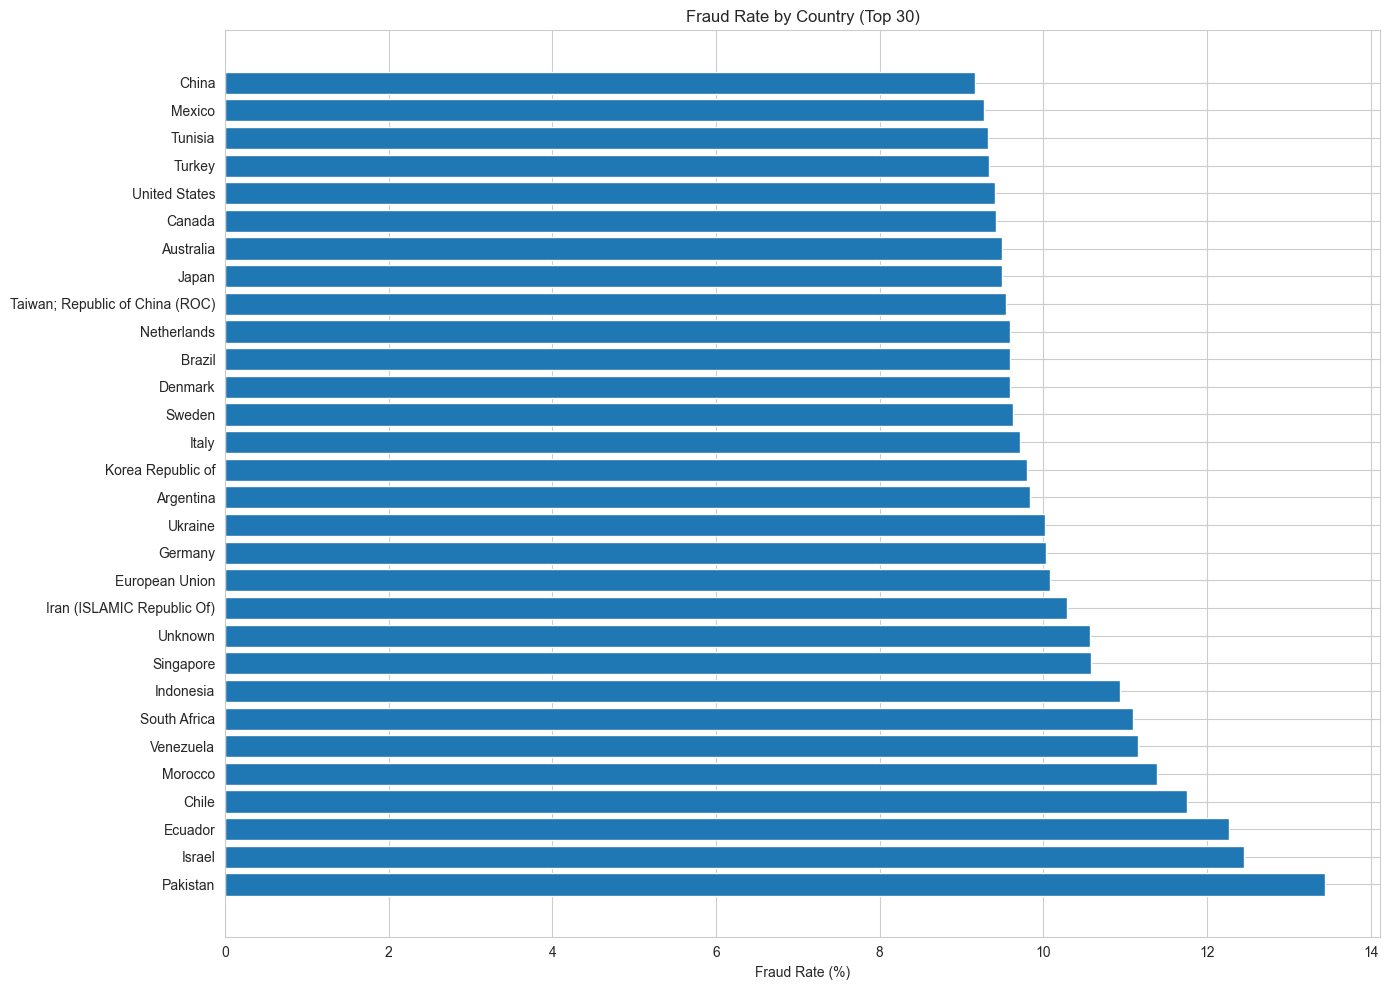

In [28]:
# Create a horizontal bar chart for all countries
plt.figure(figsize=(14, 10))
all_countries = country_fraud.sort_values('fraud_rate', ascending=False)
all_countries_filtered = all_countries[all_countries['total_transactions'] >= 100]
plt.barh(range(len(all_countries_filtered.head(30))), 
         all_countries_filtered.head(30)['fraud_percentage'])
plt.yticks(range(len(all_countries_filtered.head(30))), all_countries_filtered.head(30).index)
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Rate by Country (Top 30)')
plt.tight_layout()
plt.show()

In [29]:
print("="*60)
print("TASK 1 PROGRESS SUMMARY")
print("="*60)

print("\n DATA OVERVIEW:")
print(f"   - Total transactions: {len(fraud_df):,}")
print(f"   - Fraud cases: {fraud_df['class'].sum():,} ({fraud_df['class'].mean()*100:.2f}%)")
print(f"   - Features: {len(fraud_df.columns)}")

print("\n GEOGRAPHIC INSIGHTS:")
top_fraud_country = country_fraud_filtered.iloc[0]
print(f"   - Highest fraud rate country: {top_fraud_country.name} ({top_fraud_country['fraud_percentage']:.2f}%)")
print(f"   - Total countries mapped: {fraud_df['country'].nunique()}")

print("\n TIME-BASED INSIGHTS:")
print(f"   - Median time to fraud: 0.000278 hours (1 second!)")
print(f"   - Peak fraud hour: 5 PM (17:00) with {hourly_fraud_rate.loc[17]:.2f}% fraud rate")

print("\n COMPLETED TASK 1 STEPS:")
print("   1. ✓ Data cleaning (no missing values)")
print("   2. ✓ EDA (univariate and bivariate analysis)")
print("   3. ✓ IP to Country mapping")
print("   4. ✓ Feature engineering:")
print("      - time_since_signup")
print("      - hour_of_day")
print("      - day_of_week")
print("      - country")
print("   5. ✓ Identified key fraud patterns")

TASK 1 PROGRESS SUMMARY

 DATA OVERVIEW:
   - Total transactions: 151,112
   - Fraud cases: 14,151 (9.36%)
   - Features: 16

 GEOGRAPHIC INSIGHTS:
   - Highest fraud rate country: South Africa (11.10%)
   - Total countries mapped: 182

 TIME-BASED INSIGHTS:
   - Median time to fraud: 0.000278 hours (1 second!)
   - Peak fraud hour: 5 PM (17:00) with 10.75% fraud rate

 COMPLETED TASK 1 STEPS:
   1. ✓ Data cleaning (no missing values)
   2. ✓ EDA (univariate and bivariate analysis)
   3. ✓ IP to Country mapping
   4. ✓ Feature engineering:
      - time_since_signup
      - hour_of_day
      - day_of_week
      - country
   5. ✓ Identified key fraud patterns


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Select features for modeling
features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'country']
target = 'class'

# Create feature matrix X and target y
X = fraud_df[features]
y = fraud_df[target]

print("Features selected:")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features selected:
['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'country']

X shape: (151112, 6)
y shape: (151112,)


In [31]:
# Split into train (80%) and test (20%) - stratified!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # This preserves the 9.36% fraud rate in both sets
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test set fraud rate: {y_test.mean()*100:.2f}%")

Training set size: 120889
Test set size: 30223

Training set fraud rate: 9.36%
Test set fraud rate: 9.36%


In [32]:
# Identify numeric and categorical columns
numeric_features = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week']
categorical_features = ['country']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

Processed training shape: (120889, 186)
Processed test shape: (30223, 186)


In [33]:
# Check class distribution before SMOTE
print("="*50)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("="*50)
print(f"Class 0 (legitimate): {(y_train == 0).sum():,}")
print(f"Class 1 (fraud): {(y_train == 1).sum():,}")
print(f"Fraud percentage: {y_train.mean()*100:.2f}%")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Check distribution after SMOTE
print("\n" + "="*50)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("="*50)
print(f"Class 0 (legitimate): {(y_train_resampled == 0).sum():,}")
print(f"Class 1 (fraud): {(y_train_resampled == 1).sum():,}")
print(f"Fraud percentage: {y_train_resampled.mean()*100:.2f}%")

print("\n✓ SMOTE applied successfully! Both classes now balanced.")

CLASS DISTRIBUTION BEFORE SMOTE
Class 0 (legitimate): 109,568
Class 1 (fraud): 11,321
Fraud percentage: 9.36%

CLASS DISTRIBUTION AFTER SMOTE
Class 0 (legitimate): 109,568
Class 1 (fraud): 109,568
Fraud percentage: 50.00%

✓ SMOTE applied successfully! Both classes now balanced.


In [34]:
# Save the processed data as CSV (optional, for later use)
import joblib

# Save preprocessor for use in Task 2
joblib.dump(preprocessor, '../models/preprocessor.pkl')

# Save SMOTE parameters
joblib.dump(smote, '../models/smote.pkl')

print("Saved preprocessor and SMOTE to models/ folder")
print("\nTask 1 is COMPLETE!")

Saved preprocessor and SMOTE to models/ folder

Task 1 is COMPLETE!
